In [1]:
import sys,os,glob,copy
sys.path.append('../')
import numpy as np
from numpy.linalg import norm
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.interpolate import LinearNDInterpolator,interp2d, griddata
from itertools import product
import matplotlib as mpl
from matplotlib.colors import LogNorm
from IPython.display import display, Markdown
import glob

defaultPars = {'figure.figsize': (5, 4), 'lines.markersize' : 4, 'axes.titlesize' : 13, 'font.size' : 13,
               'axes.labelsize' : 16, 'xtick.labelsize' : 13, 'ytick.labelsize' : 13, 'legend.fontsize' : 10,
               "text.usetex": True, "font.family": "sans-serif", "font.sans-serif": ["Helvetica"],
               'font.family':'Times New Roman', 'font.serif':'Times New Roman', "savefig.dpi" : 300,
               'contour.linewidth' : 2.0, 'lines.linewidth' : 2.0, 'axes.grid' : True,
               'grid.linewidth' : 0.5, 'grid.color' : 'lightgray', 'axes.axisbelow' : True
               }
plt.rcParams.update(defaultPars) #Figure resolution
pd.set_option('display.max_rows', 200)

In [2]:
cmsCurve = np.genfromtxt('../../CMS-EXO-20-004/AuxInfo/CMS-EXO-20-004-data/HEPData-ins1894408-v2-csv/2Dexclusioncontour,fermionportal,Observed.csv',
                        skip_header=9,names=True,delimiter=',')

In [3]:
print(cmsCurve.dtype.names)

('m_Phi_GeV', 'm_chi_GeV')


In [4]:
# inputFiles = ['../../CMS-EXO-20-004/scanResults_S3D_uR_CMS_BPs_nocut.pcl']
inputFiles = ['../../t-channel/DMSimp_S3D_uR_1j_CMS-BPs_v2/Events/run_01/scanResults_1j2j.pcl']
dfs = [pd.read_pickle(i) for i in inputFiles]
recastData = pd.concat(dfs, ignore_index=True)

In [5]:
models = []
mCols = ['$m_{med}$','$m_{DM}$']
for row in recastData[mCols].values:
    m = dict(zip(mCols,row.tolist()))
    if m not in models:
        models.append(m)
print('%i models loaded' %len(models))

48 models loaded


In [6]:
parameters = {label : list(set([m[label] for m in models])) for label in mCols}
for k,v in parameters.items():
    if len(v) == 1:
        parameters[k] = v[0]
print(parameters)

textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in parameters.items() if k not in ['$m_{med}$','$m_{DM}$']])
print(textstr)

{'$m_{med}$': [1600.0, 100.0, 1000.0, 1800.0, 300.0, 750.0, 1200.0, 2000.0, 500.0, 1400.0, 2200.0], '$m_{DM}$': [800.0, 1.0, 900.0, 550.0, 200.0, 650.0, 75.0, 750.0, 400.0, 500.0, 600.0, 700.0, 350.0]}



In [7]:
# Remove duplicated data from other datasets
recastData = recastData[recastData['Data-takingperiod'] == 2017]

In [8]:
recastData = recastData[~np.isnan(recastData['$\mu^{UL}_{obs}$'])]

In [9]:
recastData

,Coupling,Mode,$m_{med}$,$m_{DM}$,Data-takingperiod,Luminosity (1/fb),bin_250.0_280.0,bin_250.0_280.0_ErrorPlus,bin_250.0_280.0_ErrorMinus,bin_280.0_310.0,...,Tauveto,Bjetveto,Photonveto,"$\Delta \phi (jet,p_{T}^{miss})>0.5$ rad",LeadingAK4jet$p_{T}>100$GeV,LeadingAK4jet$\eta<2.4$,HCALmitigation(jets),HCALmitigation($\phi^{miss}$),$\mu^{UL}_{obs}$,$\mu^{UL}_{exp}$
1,tchannel,DM+QCDjets,100.0,1.0,2017,41.5,206159.122121,23352.662344,23352.662344,117269.304420,...,0.247602,0.214212,0.213477,0.210541,0.206924,0.206924,0.206924,0.206924,0.002495,0.001312
4,tchannel,DM+QCDjets,100.0,75.0,2017,41.5,131182.477562,14081.422635,14081.422635,108201.405690,...,0.285791,0.245966,0.243794,0.242459,0.240680,0.240680,0.240680,0.240680,0.002405,0.001309
7,tchannel,DM+QCDjets,300.0,1.0,2017,41.5,39223.247714,1289.776234,1289.776234,26094.861300,...,0.302571,0.266880,0.263516,0.262457,0.258987,0.258987,0.258987,0.258987,0.024900,0.015847
10,tchannel,DM+QCDjets,300.0,200.0,2017,41.5,10884.001243,494.546881,494.546881,7662.745083,...,0.314792,0.271185,0.268115,0.267892,0.260550,0.260550,0.260550,0.260550,0.026828,0.014705
13,tchannel,DM+QCDjets,500.0,1.0,2017,41.5,8720.326213,277.538293,277.538293,6867.132616,...,0.517824,0.465718,0.458839,0.457580,0.454685,0.454685,0.454685,0.454685,0.065624,0.042966
16,tchannel,DM+QCDjets,500.0,200.0,2017,41.5,5141.896783,144.779325,144.779325,4188.239633,...,0.494414,0.436984,0.429410,0.428473,0.426318,0.426318,0.426318,0.426318,0.104930,0.059972
19,tchannel,DM+QCDjets,500.0,400.0,2017,41.5,1210.727036,47.890484,47.890484,933.339460,...,0.397225,0.342958,0.337576,0.336537,0.329186,0.329186,0.329186,0.329186,0.147270,0.070158
22,tchannel,DM+QCDjets,750.0,1.0,2017,41.5,1126.182457,49.180861,49.180861,1097.361589,...,0.695447,0.615651,0.605165,0.602401,0.599726,0.599726,0.599726,0.599726,0.159698,0.087913
25,tchannel,DM+QCDjets,750.0,200.0,2017,41.5,846.910228,31.029010,31.029010,833.189053,...,0.685052,0.606552,0.597113,0.595703,0.593220,0.593220,0.593220,0.593220,0.209011,0.114000
28,tchannel,DM+QCDjets,750.0,400.0,2017,41.5,554.162897,17.052783,17.052783,528.593313,...,0.613460,0.541326,0.533661,0.533016,0.531264,0.531264,0.531264,0.531264,0.440229,0.237131


In [14]:
kfactor = 0.85
lmuData = np.log10(recastData['$\mu^{UL}_{obs}$']/kfactor)

/tmp/ipykernel_91348/3270980453.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  c=lmuData,cmap=plt.cm.get_cmap('Reds_r', 6),s=60)


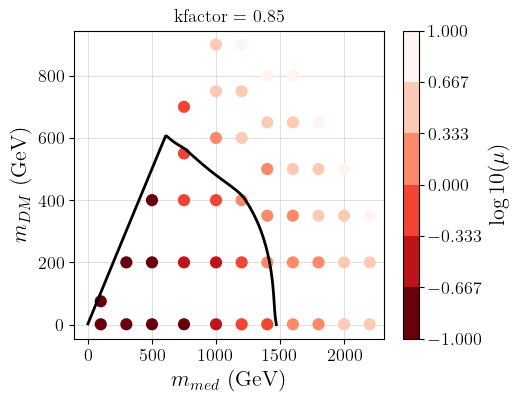

In [15]:
plt.scatter(x=recastData['$m_{med}$'],y=recastData['$m_{DM}$'],vmin=-1.0,vmax=1.0,
            c=lmuData,cmap=plt.cm.get_cmap('Reds_r', 6),s=60)
cbar = plt.colorbar(label=r'$\log10(\mu)$')
cbar.set_ticks([-1.0,-0.6666,-0.3333,0.0,0.33333,0.66666,1.0])
plt.plot(cmsCurve['m_Phi_GeV'],cmsCurve['m_chi_GeV'],label='CMS',linewidth=2,color='black')
plt.xlabel(r'$m_{med}$ (GeV)')
plt.ylabel(r'$m_{DM}$ (GeV)')
# plt.ylim(-10,1400)
# plt.xlim(0,3100)
plt.title('kfactor = %1.2f' %kfactor)
plt.text(0.04,0.75,textstr,fontsize=16,bbox=dict(facecolor='none', edgecolor='black'),
         transform = plt.gca().transAxes)
plt.show()

In [16]:
pts = np.array([x for x in product(np.linspace(0.,2000.,300),np.linspace(0.,1000.,300))])
lmuPts = griddata(list(zip(recastData['$m_{med}$'],recastData['$m_{DM}$'])),
                  lmuData,pts)
pts = pts[~np.isnan(lmuPts)]
lmuPts = lmuPts[~np.isnan(lmuPts)]

/tmp/ipykernel_91348/1163631148.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  c=lmuPts,cmap=plt.cm.get_cmap('Reds_r', 6))


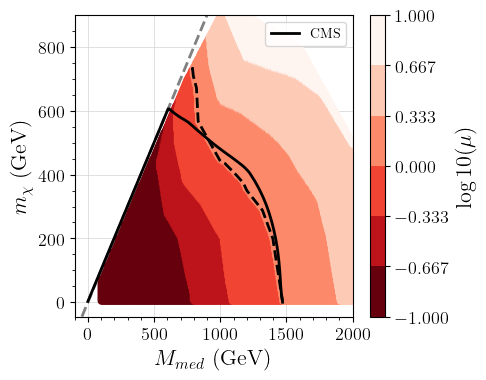

In [17]:
fig,ax = plt.subplots()

p = ax.scatter(x=pts[:,0],y=pts[:,1],vmin=-1.0,vmax=1.0,
            c=lmuPts,cmap=plt.cm.get_cmap('Reds_r', 6))
cbar = plt.colorbar(p,label=r'$\log10(\mu)$',ax=ax)
cbar.set_ticks([-1.0,-0.6666,-0.3333,0.0,0.33333,0.66666,1.0])
cs = ax.tricontour(pts[:,0],pts[:,1],lmuPts,levels=[0.0],
               linewidths=2,linestyles='--',colors='black')
# cs.collections[0].set_label('kfactor = %1.2f' %kfactor)

ax.axline((1, 1), slope=1, linestyle='--', color='gray')

ax.plot(cmsCurve['m_Phi_GeV'],cmsCurve['m_chi_GeV'],label='CMS',linewidth=2,color='black')
ax.legend(loc='upper right')
ax.set_xlabel(r'$M_{med}$ (GeV)')
ax.set_ylabel(r'$m_{\chi}$ (GeV)')
# ax.set_ylim(10,1400)
# ax.set_xlim(10,3000)
ax.minorticks_on()
ax.text(0.05,0.75,textstr,fontsize=14,bbox=dict(facecolor='white'),
         transform = ax.transAxes)
# ax[0].set_title('kfactor = %1.2f' %kfactor)

plt.tight_layout()

# plt.savefig('validation_plot_CMS_default.png')

plt.show()

In [14]:
pd.read_pickle('/home/camila/MG5/DMSimpt_S3D_uR_1j2j/Events/run_01/ys3u1_750_550_cms_exo_20_004.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,110.235906,129.674547,144.849228
bin_250.0_280.0_ErrorPlus,2.62914,2.855674,3.013771
bin_250.0_280.0_ErrorMinus,2.62914,2.855674,3.013771
bin_280.0_310.0,91.988666,104.404314,118.199479
bin_280.0_310.0_ErrorPlus,2.404975,2.560189,2.726779
bin_280.0_310.0_ErrorMinus,2.404975,2.560189,2.726779
bin_310.0_340.0,73.866836,87.097653,97.882963
bin_310.0_340.0_ErrorPlus,2.153998,2.336982,2.477454


In [14]:
recastData[recastData['$m_{DM}$']==550].T

,31
Coupling,tchannel
Mode,DM+QCDjets
$m_{med}$,750.0
$m_{DM}$,550.0
Data-takingperiod,2017
Luminosity (1/fb),41.5
bin_250.0_280.0,361.341362
bin_250.0_280.0_ErrorPlus,10.631007
bin_250.0_280.0_ErrorMinus,10.631007
bin_280.0_310.0,277.416732


In [15]:
pd.read_pickle('../../../MG5/DMsimp_t-S3D_uR_PhiPhiToJJChiChi/Events/run_04/ys3u1_750_550_cms_exo_20_004.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,291.074612,341.403374,381.829749
bin_250.0_280.0_ErrorPlus,9.317909,10.099758,10.618742
bin_250.0_280.0_ErrorMinus,9.317909,10.099758,10.618742
bin_280.0_310.0,204.876323,250.124936,301.095635
bin_280.0_310.0_ErrorPlus,7.62677,8.480365,9.287392
bin_280.0_310.0_ErrorMinus,7.62677,8.480365,9.287392
bin_310.0_340.0,179.584008,218.164643,222.071385
bin_310.0_340.0_ErrorPlus,7.132102,7.916912,8.034273


In [24]:
recastData[recastData['$m_{DM}$']==550].T

,31
Coupling,tchannel
Mode,DM+QCDjets
$m_{med}$,750.0
$m_{DM}$,550.0
Data-takingperiod,2017
Luminosity (1/fb),41.5
bin_250.0_280.0,319.157228
bin_250.0_280.0_ErrorPlus,8.091402
bin_250.0_280.0_ErrorMinus,8.091402
bin_280.0_310.0,256.76972


In [15]:
pd.read_pickle('/home/camila/MG5/DMsimp_t-S3D_uR_PhiPhiToJChiChi/Events/run_07/ys3u1_750_550_cms_exo_20_004.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,289.757848,320.709415,401.304707
bin_250.0_280.0_ErrorPlus,9.261603,9.705864,10.985743
bin_250.0_280.0_ErrorMinus,9.261603,9.705864,10.985743
bin_280.0_310.0,218.565911,245.315853,292.685808
bin_280.0_310.0_ErrorPlus,7.912579,8.366096,9.146911
bin_280.0_310.0_ErrorMinus,7.912579,8.366096,9.146911
bin_310.0_340.0,193.108915,209.453355,224.363985
bin_310.0_340.0_ErrorPlus,7.521925,7.770169,7.984606


In [16]:
pd.read_pickle('/home/camila/ys3u1_750_550_cms_exo_20_004.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,305.789534,369.557156,418.973547
bin_250.0_280.0_ErrorPlus,9.74799,10.754427,11.452825
bin_250.0_280.0_ErrorMinus,9.74799,10.754427,11.452825
bin_280.0_310.0,240.670219,290.467469,328.080258
bin_280.0_310.0_ErrorPlus,8.580473,9.47894,10.07015
bin_280.0_310.0_ErrorMinus,8.580473,9.47894,10.07015
bin_310.0_340.0,192.461501,235.372255,272.188113
bin_310.0_340.0_ErrorPlus,7.636344,8.470132,9.087598


In [17]:
pd.read_pickle('/home/camila/events_w/ys3u1_750_550_cms_exo_20_004_1j.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,233.579791,282.023188,345.112263
bin_250.0_280.0_ErrorPlus,9.365696,10.291172,11.384203
bin_250.0_280.0_ErrorMinus,9.365696,10.291172,11.384203
bin_280.0_310.0,185.887454,235.081912,259.491375
bin_280.0_310.0_ErrorPlus,8.35502,9.395763,9.871517
bin_280.0_310.0_ErrorMinus,8.35502,9.395763,9.871517
bin_310.0_340.0,153.591856,165.608823,215.554341
bin_310.0_340.0_ErrorPlus,7.594628,7.886134,8.997064


In [19]:
pd.read_pickle('/home/camila/MG5/DMsimp_t-S3D_uR_PhiPhiToJChiChi/Events/run_07/ys3u1_750_550_cms_exo_20_004_1j.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,219.524726,263.357221,300.306928
bin_250.0_280.0_ErrorPlus,8.917582,9.767379,10.430091
bin_250.0_280.0_ErrorMinus,8.917582,9.767379,10.430091
bin_280.0_310.0,166.635931,184.748532,208.657166
bin_280.0_310.0_ErrorPlus,7.76944,8.180803,8.694049
bin_280.0_310.0_ErrorMinus,7.76944,8.180803,8.694049
bin_310.0_340.0,125.701452,158.304134,177.503492
bin_310.0_340.0_ErrorPlus,6.748008,7.572714,8.01879


In [21]:
pd.read_pickle('/home/camila/MG5/DMsimp_t-S3D_uR_PhiPhiToJJChiChi/Events/run_04/ys3u1_750_550_cms_exo_20_004_2j.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,63.857985,71.979055,87.735318
bin_250.0_280.0_ErrorPlus,2.107623,2.237356,2.4697
bin_250.0_280.0_ErrorMinus,2.107623,2.237356,2.4697
bin_280.0_310.0,58.027473,63.233287,77.046047
bin_280.0_310.0_ErrorPlus,2.011718,2.1019,2.316701
bin_280.0_310.0_ErrorMinus,2.011718,2.1019,2.316701
bin_310.0_340.0,49.004062,51.364031,58.027473
bin_310.0_340.0_ErrorPlus,1.844292,1.893276,2.009321


In [22]:
pd.read_pickle('/home/camila/events_w/ys3u1_750_550_cms_exo_20_004_1j.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,233.579791,282.023188,345.112263
bin_250.0_280.0_ErrorPlus,9.365696,10.291172,11.384203
bin_250.0_280.0_ErrorMinus,9.365696,10.291172,11.384203
bin_280.0_310.0,185.887454,235.081912,259.491375
bin_280.0_310.0_ErrorPlus,8.35502,9.395763,9.871517
bin_280.0_310.0_ErrorMinus,8.35502,9.395763,9.871517
bin_310.0_340.0,153.591856,165.608823,215.554341
bin_310.0_340.0_ErrorPlus,7.594628,7.886134,8.997064


In [23]:
pd.read_pickle('/home/camila/events_w/ys3u1_750_550_cms_exo_20_004_2j.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,64.144377,74.892894,86.196173
bin_250.0_280.0_ErrorPlus,2.111333,2.278918,2.444851
bin_250.0_280.0_ErrorMinus,2.111333,2.278918,2.444851
bin_280.0_310.0,53.881276,62.410745,72.465809
bin_280.0_310.0_ErrorPlus,1.937949,2.087281,2.241687
bin_280.0_310.0_ErrorMinus,1.937949,2.087281,2.241687
bin_310.0_340.0,47.432166,51.246156,61.925328
bin_310.0_340.0_ErrorPlus,1.818909,1.88512,2.072252


In [24]:
pd.read_pickle('../DMSimp_S3D_uR_1j_test/Events/run_01/ys3u1_750_550_cms_exo_20_004.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,233.108541,287.24988,307.928863
bin_250.0_280.0_ErrorPlus,9.361864,10.392336,10.759905
bin_250.0_280.0_ErrorMinus,9.361864,10.392336,10.759905
bin_280.0_310.0,189.118704,223.333022,277.098379
bin_280.0_310.0_ErrorPlus,8.432386,9.163465,10.20705
bin_280.0_310.0_ErrorMinus,8.432386,9.163465,10.20705
bin_310.0_340.0,148.136718,179.343184,195.134408
bin_310.0_340.0_ErrorPlus,7.46302,8.21156,8.56545
